## Importing Needed Data

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
import time
import ollama
from tqdm.auto import tqdm
from sklearn.metrics import (
    r2_score, mean_squared_error,
    accuracy_score, roc_auc_score, confusion_matrix, classification_report
)

# Load shared artifacts from Notebook 1
mi = joblib.load('model_inputs.pkl')
X_train     = mi['X_train']
X_test      = mi['X_test']
y_train_reg = mi['y_train_reg']
y_test_reg  = mi['y_test_reg']
y_train_clf = mi['y_train_clf']
y_test_clf  = mi['y_test_clf']

# Load MLR and RF metrics for inline three-way comparisons (Steps 6 and 8)
mlr_metrics      = joblib.load('mlr_metrics.pkl')
rf_metrics       = joblib.load('rf_metrics.pkl')
r2_test          = mlr_metrics['regression']['r2_test']
rmse_test_euros  = mlr_metrics['regression']['rmse_test_euros']
r2_test_rf       = rf_metrics['regression']['r2_test']
rmse_test_euros_rf = rf_metrics['regression']['rmse_test_euros']
auc              = mlr_metrics['classification']['roc_auc']
accuracy_rf      = rf_metrics['classification']['accuracy']
auc_rf           = rf_metrics['classification']['roc_auc']

# Load df_clean once; reset index to align with X_train/X_test;
# then conditionally add Log_premium so it survives into later steps.
df_clean = pd.read_pickle('df_clean.pkl')
df_clean = df_clean.reset_index(drop=True)
if 'Log_premium' not in df_clean.columns:
    df_clean['Log_premium'] = np.log1p(df_clean['Premium'])

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")


X_train: (83032, 22)  |  X_test: (20759, 22)


## Part VII. LLM Prediction with Ollama

Ollama 3.2 was chosen as a model for this task due to the low cost of running the model locally. LLM model selection was not an experimental variable in this project.

**Note:** Because the LLM pulls 6 extreme samples of claims data, we do not need to balance the dataset prior to running the model, as we did with MLR and RF.

### Step 1: Imports and Ollama setup

In [2]:
# --- Ollama configuration ---
# Swap LLM_MODEL to whatever you have pulled locally (`ollama list` to check).
# Common options: 'llama3.1:8b', 'llama3.2:3b', 'qwen2.5:7b', 'gpt-oss:20b'
LLM_MODEL = 'llama3.2'
LLM_OPTIONS = {
    'temperature': 0.0,    # Deterministic for reproducibility
    'num_predict': 120,    # Cap output length — JSON is short
    'top_p': 1.0,
}

# Connectivity + speed sanity check
print(f"Testing Ollama connection with model: {LLM_MODEL}")
t0 = time.time()
test_response = ollama.chat(
    model=LLM_MODEL,
    messages=[{'role': 'user', 'content': 'Reply with exactly the word: OK'}],
    options=LLM_OPTIONS,
)
print(f"Response: {test_response['message']['content'].strip()!r}")
print(f"Round-trip latency: {time.time() - t0:.2f}s")


Testing Ollama connection with model: llama3.2
Response: 'OK'
Round-trip latency: 1.97s


Because latency is relatively low, we can utilize this LLM over a wide range of test data without overly worrying about loading time.

In [3]:
# --- Data views with original column values for prompt construction ---
# (X_train/X_test are post-encoding; we want the human-readable version)
train_view = df_clean.loc[X_train.index]
test_view  = df_clean.loc[X_test.index]

print(f"train_view: {train_view.shape}, test_view: {test_view.shape}")

train_view: (83032, 32), test_view: (20759, 32)


### Step 2: Design few-shot prompt templates

In [4]:
# --- Helper: convert a policy row to readable feature text ---
# Uses df_clean so we get readable categoricals (Risk_tier as string, etc.)

def policy_to_text(idx, source_df=df_clean):
    """Convert a single policy row into a structured, human-readable description for the LLM."""
    row = source_df.loc[idx]
    lines = [
        f"Driver age: {int(row['Driver_age'])} years",
        f"Licence years: {int(row['Licence_years'])}",
        f"Seniority with insurer: {int(row['Seniority'])} years",
        f"Vehicle age: {int(row['Vehicle_age'])} years",
        f"Vehicle power: {int(row['Power'])} kW",          # dataset is European — kW, not hp
        f"Vehicle value: EUR {int(row['Value_vehicle'])}",
        f"Vehicle weight: {int(row['Weight'])} kg",
        f"Cylinder capacity: {int(row['Cylinder_capacity'])} cc",
        f"Number of doors: {int(row['N_doors'])}",
        f"Risk tier: {row['Risk_tier']}",
        f"Type of risk (categorical, 1-4): {int(row['Type_risk'])}",
        f"Fuel: {'diesel' if row['Fuel_diesel']==1 else 'petrol'}",
        f"Active policy: {'yes' if row['Is_active']==1 else 'no'}",
        f"Policies currently in force: {int(row['Policies_in_force'])}",
        f"Max policies ever held: {int(row['Max_policies'])}",
        f"Number of prior claims: {int(row['N_claims_history'])}",
        f"Prior claims ratio: {row['R_Claims_history']:.3f}",
    ]
    return "\n".join(lines)


# --- Few-shot pool for the CLAIM task (balanced + varied probabilities) ---
# 3 claimers + 3 non-claimers, with a range of probabilities so the model
# sees that probability is supposed to vary by policy profile.
# Defensive: fall back to broader pools if a strict filter returns empty.
np.random.seed(43)

def safe_pick(strict_pool, fallback_pool, label):
    """Pick from strict_pool if non-empty, else fall back. Print which we used."""
    if len(strict_pool) > 0:
        return int(np.random.choice(strict_pool, 1)[0])
    print(f"  [warn] {label}: strict pool empty, falling back to broader pool")
    return int(np.random.choice(fallback_pool, 1)[0])

# Pools, strict to broad
claimers_heavy_history = train_view.query(
    "Claim_occurred == 1 and N_claims_history >= 2"
).index
claimers_some_history = train_view.query(
    "Claim_occurred == 1 and N_claims_history >= 1"
).index
claimers_any = train_view.query("Claim_occurred == 1").index

non_claimers_clean = train_view.query(
    "Claim_occurred == 0 and N_claims_history == 0 and Seniority >= 5"
).index
non_claimers_no_history = train_view.query(
    "Claim_occurred == 0 and N_claims_history == 0"
).index
non_claimers_with_history = train_view.query(
    "Claim_occurred == 0 and N_claims_history >= 1"
).index
non_claimers_any = train_view.query("Claim_occurred == 0").index

# Sanity check sizes so we know what's happening
print("Few-shot candidate pool sizes:")
print(f"  claimers (>=2 prior):       {len(claimers_heavy_history)}")
print(f"  claimers (>=1 prior):       {len(claimers_some_history)}")
print(f"  claimers (any):             {len(claimers_any)}")
print(f"  non-claimers (clean+sen):   {len(non_claimers_clean)}")
print(f"  non-claimers (no prior):    {len(non_claimers_no_history)}")
print(f"  non-claimers (with prior):  {len(non_claimers_with_history)}")
print(f"  non-claimers (any):         {len(non_claimers_any)}")
print()

# Build the 6-example pool with fallbacks
claim_fewshot = [
    (safe_pick(claimers_heavy_history, claimers_any, "claimer #1"),       0.90, 1),
    (safe_pick(claimers_heavy_history, claimers_any, "claimer #2"),       0.80, 1),
    (safe_pick(claimers_some_history, claimers_any, "claimer #3"),        0.55, 1),
    (safe_pick(non_claimers_with_history, non_claimers_any, "non-cl #1"), 0.35, 0),
    (safe_pick(non_claimers_clean, non_claimers_no_history, "non-cl #2"), 0.15, 0),
    (safe_pick(non_claimers_clean, non_claimers_no_history, "non-cl #3"), 0.08, 0),
]
print(f"Claim few-shot pool ({len(claim_fewshot)}): "
      f"{[(i, p, c) for i, p, c in claim_fewshot]}")

Few-shot candidate pool sizes:
  claimers (>=2 prior):       12572
  claimers (>=1 prior):       15599
  claimers (any):             15599
  non-claimers (clean+sen):   6676
  non-claimers (no prior):    28612
  non-claimers (with prior):  38821
  non-claimers (any):         67433

Claim few-shot pool (6): [(61235, 0.9, 1), (30174, 0.8, 1), (22801, 0.55, 1), (28742, 0.35, 0), (70261, 0.15, 0), (70594, 0.08, 0)]


Prompt engineering. This queries the dataset for a set of example rows to be pulled as few-shot examples before the LLM outputs a prediction. The general ideas is that the LLM will be provided with a wide range of examples to better predict a result.

The downside here is that the LLM cannot process the entire dataset (like the ML models) to mathematically compute likelihoods-- LLMs are designed for pattern recognition. The LLM is *not designed* for this task.

In [5]:
# Re-use the same 6 anchor policies for both tasks (parsimony + same examples for both)
fewshot_idx = [idx for idx, _, _ in claim_fewshot]

# --- CLAIM prompt: few-shot blocks + new policy ---
def _format_claim_example(idx, prob, label):
    return (
        f"POLICY:\n{policy_to_text(idx, train_view)}\n"
        f'OUTPUT: {{"claim_probability": {prob}, "claim_predicted": {label}}}'
    )

_claim_fewshot_block = "\n\n".join(
    _format_claim_example(idx, prob, label) for idx, prob, label in claim_fewshot
)

def build_claim_prompt(idx):
    return f"""You are an insurance underwriter estimating the probability of a motor insurance claim in the next year.
Study the examples, then evaluate the new policy.
Respond with ONLY a JSON object with two keys:
  "claim_probability": float between 0 and 1
  "claim_predicted":   integer, 1 if claim_probability > 0.5 else 0

{_claim_fewshot_block}

POLICY:
{policy_to_text(idx)}
OUTPUT:"""

# --- PREMIUM prompt: same anchor policies, swap in actual euro premiums ---
premium_fewshot = [(idx, float(df_clean.loc[idx, 'Premium'])) for idx in fewshot_idx]

def _format_premium_example(idx, premium):
    return (
        f"POLICY:\n{policy_to_text(idx, train_view)}\n"
        f'OUTPUT: {{"predicted_premium_eur": {premium:.2f}}}'
    )

_premium_fewshot_block = "\n\n".join(
    _format_premium_example(idx, prem) for idx, prem in premium_fewshot
)

def build_premium_prompt(idx):
    return f"""You are an insurance underwriter estimating the annual motor policy premium in EUR.
Study the examples, then estimate the premium for the new policy.
Respond with ONLY a JSON object with one key:
  "predicted_premium_eur": positive number representing annual premium in EUR

{_premium_fewshot_block}

POLICY:
{policy_to_text(idx)}
OUTPUT:"""

print(f"Few-shot pool size: {len(fewshot_idx)} anchor policies (used for both tasks)")
print(f"Premium few-shot anchors (idx, €): {[(i, round(p,2)) for i,p in premium_fewshot]}")

Few-shot pool size: 6 anchor policies (used for both tasks)
Premium few-shot anchors (idx, €): [(61235, 131.2), (30174, 465.67), (22801, 218.27), (28742, 273.58), (70261, 238.6), (70594, 184.21)]


Examples and primary prompt are designed here and will be provided to the LLM when it is called.

### Step 3: Define batch inference function

In [6]:
# --- Robust JSON extraction ---
# Even with temperature=0, LLMs sometimes wrap output in code fences or add prose.
# Strategy: regex for {...}, json.loads it, retry once with stricter reminder if it fails.

# If regex is not finding the JSON, it returns None. If json.loads fails, it also returns None.
def extract_json(text):
    """Pull the first JSON object out of an LLM response, return dict or None."""
    text = text.strip().strip('`')
    match = re.search(r'\{[^{}]*\}', text, re.DOTALL)
    if not match:
        return None
    try:
        return json.loads(match.group(0))
    except json.JSONDecodeError:
        return None

# If JSON returns None, the prompt is retried once with a reminder to respond ONLY with JSON. If it still fails, we return None and log the raw output for analysis.
def call_llm(prompt, max_retries=2):
    """Single LLM call with retry-on-malformed-output."""
    for attempt in range(max_retries):
        response = ollama.chat(
            model=LLM_MODEL,
            messages=[{'role': 'user', 'content': prompt}],
            options=LLM_OPTIONS,
        )
        raw = response['message']['content']
        parsed = extract_json(raw)
        if parsed is not None:
            return parsed, raw
        # Retry with stricter reminder
        prompt = prompt + "\n\nREMINDER: respond ONLY with the JSON object, nothing else."
    return None, raw  # Failed after retries; caller handles None


# --- Batch inference loop ---
def run_batch_inference(indices, prompt_builder, label="inference"):
    """Loop LLM over a list of policy indices, return predictions list + parse-failure log."""
    predictions = []
    failures = []
    for idx in tqdm(indices, desc=label):
        prompt = prompt_builder(idx)
        parsed, raw = call_llm(prompt)
        if parsed is None:
            failures.append({'idx': idx, 'raw': raw[:200]})
            predictions.append(None)
        else:
            predictions.append(parsed)
    return predictions, failures

This code block is designed to ensure that the LLM does not return improperly formatted responses. If the LLM does so, it is prompted again with a reminder. If it fails twice, it is flagged and the instance is brought to human attention.

### Step 4: Pilot run on small sample

In [7]:
# Pilot: 15 rows from the test set, stratified on Claim_occurred for a useful first look
np.random.seed(42)
pilot_claim_idx = np.random.choice(test_view.query("Claim_occurred == 1").index, 5, replace=False)
pilot_no_claim_idx = np.random.choice(test_view.query("Claim_occurred == 0").index, 10, replace=False)
pilot_idx = list(pilot_claim_idx) + list(pilot_no_claim_idx)

print("=" * 60)
print("PILOT: Premium prediction on 15 test rows")
print("=" * 60)
t0 = time.time()
pilot_premium_preds, pilot_premium_fails = run_batch_inference(
    pilot_idx, build_premium_prompt, label="premium pilot"
)
pilot_premium_time = time.time() - t0
print(f"Done in {pilot_premium_time:.1f}s ({pilot_premium_time/len(pilot_idx):.2f}s per row)")
print(f"Parse failures: {len(pilot_premium_fails)}/{len(pilot_idx)}")

print("\n" + "=" * 60)
print("PILOT: Claim prediction on same 15 test rows")
print("=" * 60)
t0 = time.time()
pilot_claim_preds, pilot_claim_fails = run_batch_inference(
    pilot_idx, build_claim_prompt, label="claim pilot"
)
pilot_claim_time = time.time() - t0
print(f"Done in {pilot_claim_time:.1f}s ({pilot_claim_time/len(pilot_idx):.2f}s per row)")
print(f"Parse failures: {len(pilot_claim_fails)}/{len(pilot_idx)}")

# Side-by-side: predicted vs actual for the pilot
print("\n" + "=" * 70)
print("Pilot predictions vs actuals")
print("=" * 70)
print(f"{'idx':>8} {'actual_€':>10} {'pred_€':>10} {'actual_clm':>12} {'pred_prob':>10} {'pred_clm':>10}")
print("-" * 70)
for i, idx in enumerate(pilot_idx):
    actual_prem = df_clean.loc[idx, 'Premium']
    actual_clm = int(df_clean.loc[idx, 'Claim_occurred'])
    pred_prem = pilot_premium_preds[i].get('predicted_premium_eur') if pilot_premium_preds[i] else None
    pred_prob = pilot_claim_preds[i].get('claim_probability') if pilot_claim_preds[i] else None
    pred_clm = pilot_claim_preds[i].get('claim_predicted') if pilot_claim_preds[i] else None
    pred_prem_s = f"{pred_prem:.2f}" if pred_prem is not None else "FAIL"
    pred_prob_s = f"{pred_prob:.2f}" if pred_prob is not None else "FAIL"
    pred_clm_s = f"{pred_clm}" if pred_clm is not None else "FAIL"
    print(f"{idx:>8} {actual_prem:>10.2f} {pred_prem_s:>10} {actual_clm:>12} {pred_prob_s:>10} {pred_clm_s:>10}")

# Time projection
SAMPLE_SIZE = 300
projected_min = ((pilot_premium_time + pilot_claim_time) / 15) * SAMPLE_SIZE / 60
print(f"\nProjected time for SAMPLE_SIZE={SAMPLE_SIZE} (both tasks): ~{projected_min:.1f} min")

PILOT: Premium prediction on 15 test rows


premium pilot:   0%|          | 0/15 [00:00<?, ?it/s]

Done in 3.4s (0.23s per row)
Parse failures: 0/15

PILOT: Claim prediction on same 15 test rows


claim pilot:   0%|          | 0/15 [00:00<?, ?it/s]

Done in 3.8s (0.25s per row)
Parse failures: 0/15

Pilot predictions vs actuals
     idx   actual_€     pred_€   actual_clm  pred_prob   pred_clm
----------------------------------------------------------------------
   86476     371.87     184.21            1       0.80          1
   78881     208.71     238.60            1       0.84          1
   22769     334.06     184.21            1       0.35          0
    2254     284.84     184.21            1       0.80          1
   31052     235.50     184.21            1       0.15          0
   75198     257.18     184.21            0       0.35          0
   10189     251.14     184.21            0       0.35          0
   40884     129.07     184.21            0       0.35          0
   28224     254.66     184.21            0       0.35          0
   58625     286.05     184.21            0       0.35          0
   36981     413.65     184.21            0       0.35          0
    2068      75.62     184.21            0       0.35   

Testing if the LLM works before committing to the larger batch.

### Step 5: Run premium prediction

In [8]:
# Stratified sample on Claim_occurred so the same indices serve both tasks
SAMPLE_SIZE = 300  # Adjust based on the pilot timing above
N_CLAIM = int(SAMPLE_SIZE * (df_clean['Claim_occurred'].mean()))  # match base rate
N_NO_CLAIM = SAMPLE_SIZE - N_CLAIM

np.random.seed(42)
sample_claim = np.random.choice(test_view.query("Claim_occurred == 1").index, N_CLAIM, replace=False)
sample_no_claim = np.random.choice(test_view.query("Claim_occurred == 0").index, N_NO_CLAIM, replace=False)
llm_sample_idx = np.concatenate([sample_claim, sample_no_claim])
np.random.shuffle(llm_sample_idx)

print(f"LLM evaluation sample: {len(llm_sample_idx)} rows")
print(f"  Claim=1: {N_CLAIM}, Claim=0: {N_NO_CLAIM}")
print(f"  Base rate: {N_CLAIM/SAMPLE_SIZE:.3f} (overall test: {y_test_clf.mean():.3f})")

print("\nRunning premium prediction across full sample...")
t0 = time.time()
llm_premium_preds, llm_premium_fails = run_batch_inference(
    llm_sample_idx, build_premium_prompt, label="LLM premium"
)
print(f"Done in {(time.time() - t0)/60:.1f} min")
print(f"Parse failures: {len(llm_premium_fails)}/{len(llm_sample_idx)} "
      f"({100*len(llm_premium_fails)/len(llm_sample_idx):.1f}%)")

LLM evaluation sample: 300 rows
  Claim=1: 56, Claim=0: 244
  Base rate: 0.187 (overall test: 0.188)

Running premium prediction across full sample...


LLM premium:   0%|          | 0/300 [00:00<?, ?it/s]

Done in 1.1 min
Parse failures: 0/300 (0.0%)


Running the larger batch for premium estimates.

### Step 6: Compute regression metrics

LLM — Premium Prediction (sample-based)
Sample size:              300 (after parse failures)
R² (test, log scale):     -2.4581
RMSE (test, log scale):   0.7834
RMSE (test, €):           2746.97
Mean actual €:            308.77
Mean predicted €:         548.47

Three-way comparison on Premium:
Model                        R² test     RMSE €
-----------------------------------------------
MLR (h2)                      0.4869     119.17
RF (h1)                       0.7175      86.31
LLM (llama3.2)               -2.4581    2746.97


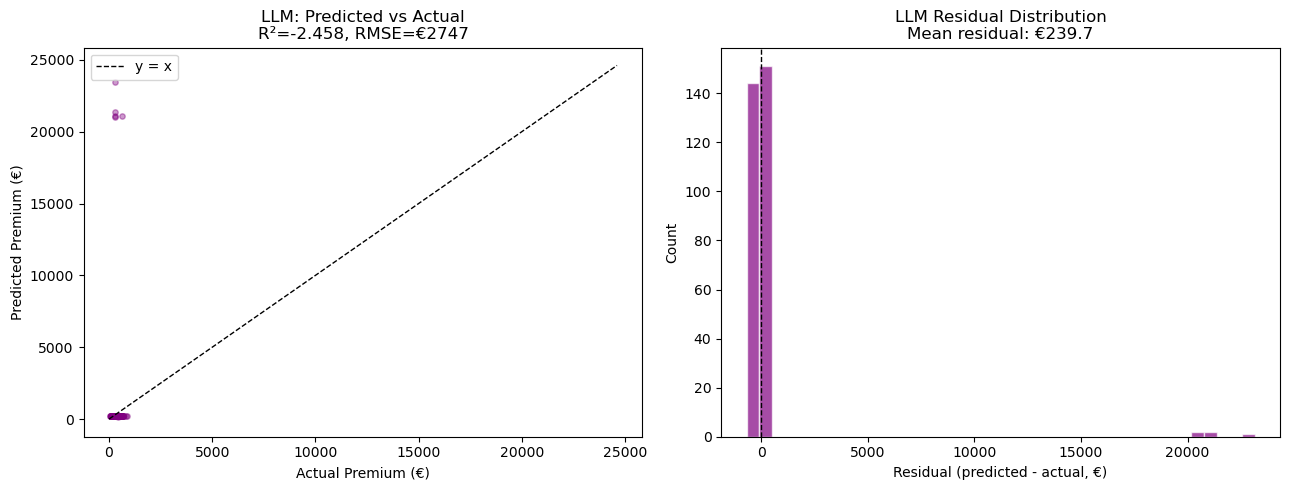

In [9]:
# Pull predictions into arrays, drop parse failures
y_actual_prem = []
y_pred_prem = []
for idx, pred in zip(llm_sample_idx, llm_premium_preds):
    if pred is None or 'predicted_premium_eur' not in pred:
        continue
    try:
        y_pred_prem.append(float(pred['predicted_premium_eur']))
        y_actual_prem.append(df_clean.loc[idx, 'Premium'])
    except (ValueError, TypeError):
        continue

y_actual_prem = np.array(y_actual_prem)
y_pred_prem = np.array(y_pred_prem)

# Compute on log scale (matches MLR/RF reporting) and euro scale
y_actual_log = np.log1p(y_actual_prem)
y_pred_log = np.log1p(np.clip(y_pred_prem, 0, None))  # guard against negative outputs

r2_test_llm = r2_score(y_actual_log, y_pred_log)
rmse_test_log_llm = np.sqrt(mean_squared_error(y_actual_log, y_pred_log))
rmse_test_euros_llm = np.sqrt(mean_squared_error(y_actual_prem, y_pred_prem))
mean_pred_llm = y_pred_prem.mean()
mean_actual_llm = y_actual_prem.mean()

print("LLM — Premium Prediction (sample-based)")
print("=" * 50)
print(f"Sample size:              {len(y_actual_prem)} (after parse failures)")
print(f"R² (test, log scale):     {r2_test_llm:.4f}")
print(f"RMSE (test, log scale):   {rmse_test_log_llm:.4f}")
print(f"RMSE (test, €):           {rmse_test_euros_llm:.2f}")
print(f"Mean actual €:            {mean_actual_llm:.2f}")
print(f"Mean predicted €:         {mean_pred_llm:.2f}")

print("\nThree-way comparison on Premium:")
print(f"{'Model':<25} {'R² test':>10} {'RMSE €':>10}")
print("-" * 47)
print(f"{'MLR (h2)':<25} {r2_test:>10.4f} {rmse_test_euros:>10.2f}")
print(f"{'RF (h1)':<25} {r2_test_rf:>10.4f} {rmse_test_euros_rf:>10.2f}")
print(f"{'LLM ({})'.format(LLM_MODEL):<25} {r2_test_llm:>10.4f} {rmse_test_euros_llm:>10.2f}")

# Quick diagnostic plot: predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_actual_prem, y_pred_prem, alpha=0.4, color='purple', s=15)
lim = [0, max(y_actual_prem.max(), y_pred_prem.max()) * 1.05]
axes[0].plot(lim, lim, 'k--', linewidth=1, label='y = x')
axes[0].set_xlabel('Actual Premium (€)')
axes[0].set_ylabel('Predicted Premium (€)')
axes[0].set_title(f'LLM: Predicted vs Actual\nR²={r2_test_llm:.3f}, RMSE=€{rmse_test_euros_llm:.0f}')
axes[0].legend()

residuals = y_pred_prem - y_actual_prem
axes[1].hist(residuals, bins=40, color='purple', edgecolor='white', alpha=0.7)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual (predicted - actual, €)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'LLM Residual Distribution\nMean residual: €{residuals.mean():.1f}')
plt.tight_layout()
plt.show()

Visualization of the regression outcome. Clearly inaccurate-- the LLM has a negative R-squared value and an RMSE of 2746.97, an enormous increase when compared with the other two approaches.

### Step 7: Run claim occurrence prediction

In [10]:
print("Running claim prediction across full sample...")
t0 = time.time()
llm_claim_preds, llm_claim_fails = run_batch_inference(
    llm_sample_idx, build_claim_prompt, label="LLM claim"
)
print(f"Done in {(time.time() - t0)/60:.1f} min")
print(f"Parse failures: {len(llm_claim_fails)}/{len(llm_sample_idx)} "
      f"({100*len(llm_claim_fails)/len(llm_sample_idx):.1f}%)")

Running claim prediction across full sample...


LLM claim:   0%|          | 0/300 [00:00<?, ?it/s]

Done in 1.2 min
Parse failures: 0/300 (0.0%)


Running claim prediction on the same dataset.

### Step 8: Compute classification metrics

LLM — Claim Occurrence (sample-based)
Sample size: 300 (after parse failures)
Accuracy: 0.7900
ROC-AUC:  0.6822

Confusion Matrix:
                 Predicted
                 No     Yes
  Actual No     210     34
  Actual Yes     29     27

Classification Report:
              precision    recall  f1-score   support

    No claim       0.88      0.86      0.87       244
       Claim       0.44      0.48      0.46        56

    accuracy                           0.79       300
   macro avg       0.66      0.67      0.67       300
weighted avg       0.80      0.79      0.79       300

Three-way comparison on Claim Occurrence:
Model                       Accuracy    ROC-AUC
-----------------------------------------------
MLR (h2)                      0.8642     0.9148
RF (h1)                       0.8233     0.8735
LLM (llama3.2)                0.7900     0.6822


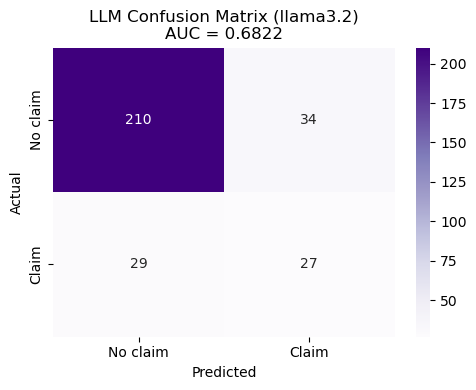

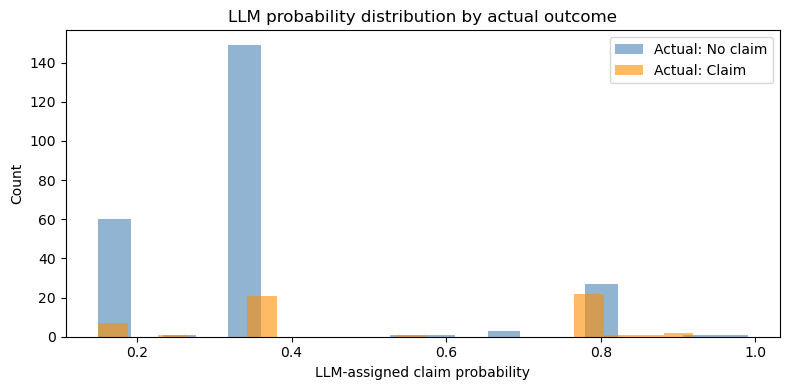

In [11]:
# Extract probabilities and binary predictions, drop parse failures
y_actual_clm = []
y_pred_clm = []
y_pred_prob = []
for idx, pred in zip(llm_sample_idx, llm_claim_preds):
    if pred is None:
        continue
    try:
        prob = float(pred.get('claim_probability', np.nan))
        binary = int(pred.get('claim_predicted', -1))
        if np.isnan(prob) or binary not in (0, 1):
            continue
        y_pred_prob.append(np.clip(prob, 0, 1))
        y_pred_clm.append(binary)
        y_actual_clm.append(int(df_clean.loc[idx, 'Claim_occurred']))
    except (ValueError, TypeError):
        continue

y_actual_clm = np.array(y_actual_clm)
y_pred_clm = np.array(y_pred_clm)
y_pred_prob = np.array(y_pred_prob)

accuracy_llm = accuracy_score(y_actual_clm, y_pred_clm)
auc_llm = roc_auc_score(y_actual_clm, y_pred_prob)
cm_llm = confusion_matrix(y_actual_clm, y_pred_clm)

print("LLM — Claim Occurrence (sample-based)")
print("=" * 50)
print(f"Sample size: {len(y_actual_clm)} (after parse failures)")
print(f"Accuracy: {accuracy_llm:.4f}")
print(f"ROC-AUC:  {auc_llm:.4f}")
print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 No     Yes")
print(f"  Actual No   {cm_llm[0,0]:>5}  {cm_llm[0,1]:>5}")
print(f"  Actual Yes  {cm_llm[1,0]:>5}  {cm_llm[1,1]:>5}")
print(f"\nClassification Report:")
print(classification_report(y_actual_clm, y_pred_clm, target_names=['No claim', 'Claim']))

print("Three-way comparison on Claim Occurrence:")
print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10}")
print("-" * 47)
accuracy_mlr = mlr_metrics['classification']['accuracy']
print(f"{'MLR (h2)':<25} {accuracy_mlr:>10.4f} {auc:>10.4f}")
print(f"{'RF (h1)':<25} {accuracy_rf:>10.4f} {auc_rf:>10.4f}")
print(f"{'LLM ({})'.format(LLM_MODEL):<25} {accuracy_llm:>10.4f} {auc_llm:>10.4f}")

# Confusion matrix heatmap to match RF style
plt.figure(figsize=(5, 4))
sns.heatmap(cm_llm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No claim', 'Claim'],
            yticklabels=['No claim', 'Claim'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'LLM Confusion Matrix ({LLM_MODEL})\nAUC = {auc_llm:.4f}')
plt.tight_layout()
plt.show()

# Probability distribution — shows whether LLM gives gradient or clumped outputs
plt.figure(figsize=(8, 4))
plt.hist(y_pred_prob[y_actual_clm==0], bins=20, alpha=0.6, label='Actual: No claim', color='steelblue')
plt.hist(y_pred_prob[y_actual_clm==1], bins=20, alpha=0.6, label='Actual: Claim', color='darkorange')
plt.xlabel('LLM-assigned claim probability')
plt.ylabel('Count')
plt.title('LLM probability distribution by actual outcome')
plt.legend()
plt.tight_layout()
plt.show()

Again, evidence of the LLM failing to perform as well as h1 and h2. While the model's accuracy remains high, as previously mentioned accuracy is an inconsistent metric for this classification task as the majority of cases will not result in a claim occurring. The LLM's low ROC-AUC score is a better representation of its shortcomings.

## Export Needed Data

In [12]:
llm_predictions_df = pd.DataFrame({
    'idx':                   llm_sample_idx,
    'actual_premium':        [df_clean.loc[i, 'Premium'] for i in llm_sample_idx],
    'predicted_premium':     [p.get('predicted_premium_eur') if p else None for p in llm_premium_preds],
    'actual_claim':          [int(df_clean.loc[i, 'Claim_occurred']) for i in llm_sample_idx],
    'predicted_claim_prob':  [p.get('claim_probability') if p else None for p in llm_claim_preds],
    'predicted_claim':       [p.get('claim_predicted') if p else None for p in llm_claim_preds],
})
joblib.dump(llm_predictions_df, 'llm_predictions.pkl')

llm_metrics = {
    'model': f'LLM ({LLM_MODEL})',
    'sample_size': SAMPLE_SIZE,
    'parse_failure_rate_premium': len(llm_premium_fails) / len(llm_sample_idx),
    'parse_failure_rate_claim':   len(llm_claim_fails)   / len(llm_sample_idx),
    'fewshot_n': len(fewshot_idx),
    'evaluation_note': (
        f'Sample-based evaluation on {SAMPLE_SIZE} stratified test rows '
        f'(full test set infeasible at local LLM throughput). '
        f'Few-shot prompting with {len(fewshot_idx)} training examples; '
        f'temperature=0 for reproducibility.'
    ),
    'regression': {
        'r2_test':           r2_test_llm,
        'rmse_test_log':     rmse_test_log_llm,
        'rmse_test_euros':   rmse_test_euros_llm,
        'mean_predicted_eur': float(mean_pred_llm),
        'mean_actual_eur':   float(mean_actual_llm),
        'effective_n':       len(y_actual_prem),
    },
    'classification': {
        'accuracy':         accuracy_llm,
        'roc_auc':          auc_llm,
        'confusion_matrix': cm_llm.tolist(),
        'effective_n':      len(y_actual_clm),
        'y_pred_prob':      y_pred_prob,    # needed for ROC curve in Notebook 5
        'y_actual_clm':     y_actual_clm,  # LLM used a subset, so we save actuals too
    },
}
joblib.dump(llm_metrics, 'llm_metrics.pkl')

print("✓ llm_predictions.pkl")
print("✓ llm_metrics.pkl")

✓ llm_predictions.pkl
✓ llm_metrics.pkl
